# 下載並製作 `S1_Hualien_dB.tif`（Sentinel-1 RTC / SAR）

透過 STAC API 搜尋 Microsoft Planetary Computer 的 `sentinel-1-rtc` collection，下載花蓮研究區的 Sentinel-1 VV 影像，裁切到作業 bbox，轉成 dB，輸出成 `S1_Hualien_dB.tif`。

**說明**：作業中的 `S1_Hualien_dB.tif` 是已前處理的 Sentinel-1 雷達資料，不是光學影像。它代表 SAR 後向散射強度，後續用低後向散射門檻擷取水體 / 淹水區。

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from pystac_client import Client
import planetary_computer as pc

import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from scipy.ndimage import median_filter, binary_opening, label

load_dotenv()

OUT_DIR = Path('output')
OUT_DIR.mkdir(exist_ok=True)

LAKE_BBOX = [
    float(os.getenv('BBOX_WEST', 121.28)),
    float(os.getenv('BBOX_SOUTH', 23.56)),
    float(os.getenv('BBOX_EAST', 121.52)),
    float(os.getenv('BBOX_NORTH', 23.76)),
]

SAR_THRESHOLD = float(os.getenv('SAR_THRESHOLD', -18))
SAR_FILE = Path(os.getenv('SAR_FILE', 'S1_Hualien_dB.tif'))

catalog = Client.open('https://planetarycomputer.microsoft.com/api/stac/v1')

print('bbox =', LAKE_BBOX)
print('SAR output =', SAR_FILE)

bbox = [121.28, 23.56, 121.52, 23.76]
SAR output = S1_Hualien_dB.tif


## 1. 搜尋 Sentinel-1 RTC 場景

先搜尋 pre/post 時段中可用的 Sentinel-1 RTC 影像，再選擇 pre/post 都存在的共同軌道方向，避免不同入射幾何造成差異。

In [2]:
def search_sar(bbox, datetime_range, orbit_state=None, max_items=30, tries=3):
    """Search sentinel-1-rtc scenes with retry and optional orbit-state filtering."""
    last_err = None
    for attempt in range(tries):
        try:
            search = catalog.search(
                collections=['sentinel-1-rtc'],
                bbox=bbox,
                datetime=datetime_range,
                max_items=max_items,
            )
            items = list(search.items())
            if orbit_state:
                items = [
                    i for i in items
                    if i.properties.get('sat:orbit_state', '').lower() == orbit_state.lower()
                ]
            items.sort(key=lambda i: i.properties.get('datetime', ''))
            return items
        except Exception as e:
            last_err = e
            time.sleep(2 ** attempt)

    raise RuntimeError(f'STAC search failed: {last_err}')


all_pre  = search_sar(LAKE_BBOX, '2025-06-15/2025-07-17')
all_post = search_sar(LAKE_BBOX, '2025-09-10/2025-09-25')

print(f'Pre-disaster: {len(all_pre)} scenes')
for it in all_pre:
    p = it.properties
    print(f"  {p.get('datetime','?')[:16]} | {p.get('sat:orbit_state','?')} | {it.id[:60]}")

print(f'\nPost-disaster: {len(all_post)} scenes')
for it in all_post:
    p = it.properties
    print(f"  {p.get('datetime','?')[:16]} | {p.get('sat:orbit_state','?')} | {it.id[:60]}")

orbits_pre  = set(i.properties.get('sat:orbit_state','').lower() for i in all_pre)
orbits_post = set(i.properties.get('sat:orbit_state','').lower() for i in all_post)

common = orbits_pre & orbits_post
print(f'\n共同軌道: {common}')

if 'ascending' in common:
    ORBIT_STATE = 'ascending'
elif 'descending' in common:
    ORBIT_STATE = 'descending'
elif common:
    ORBIT_STATE = sorted(common)[0]
else:
    ORBIT_STATE = sorted(orbits_post)[0] if orbits_post else None
    print(f'⚠ 沒有共同軌道，暫用 {ORBIT_STATE}')

print(f'→ 選定: {ORBIT_STATE}')

items_pre  = [
    i for i in all_pre
    if i.properties.get('sat:orbit_state','').lower() == ORBIT_STATE
]
items_post = [
    i for i in all_post
    if i.properties.get('sat:orbit_state','').lower() == ORBIT_STATE
]

print(f'PRE ({ORBIT_STATE}): {len(items_pre)} | POST ({ORBIT_STATE}): {len(items_post)}')

Pre-disaster: 10 scenes
  2025-06-16T21:53 | descending | S1A_IW_GRDH_1SDV_20250616T215252_20250616T215317_059677_rtc
  2025-06-22T21:51 | descending | S1C_IW_GRDH_1SDV_20250622T215117_20250622T215146_002901_rtc
  2025-06-22T21:51 | descending | S1C_IW_GRDH_1SDV_20250622T215146_20250622T215211_002901_rtc
  2025-06-26T10:01 | ascending | S1A_IW_GRDH_1SDV_20250626T100124_20250626T100149_059816_076D
  2025-06-28T21:53 | descending | S1A_IW_GRDH_1SDV_20250628T215251_20250628T215316_059852_076F
  2025-07-04T21:51 | descending | S1C_IW_GRDH_1SDV_20250704T215118_20250704T215147_003076_rtc
  2025-07-04T21:51 | descending | S1C_IW_GRDH_1SDV_20250704T215147_20250704T215212_003076_rtc
  2025-07-10T21:53 | descending | S1A_IW_GRDH_1SDV_20250710T215251_20250710T215316_060027_rtc
  2025-07-16T21:51 | descending | S1C_IW_GRDH_1SDV_20250716T215118_20250716T215148_003251_rtc
  2025-07-16T21:52 | descending | S1C_IW_GRDH_1SDV_20250716T215148_20250716T215213_003251_rtc

Post-disaster: 4 scenes
  2025-09-

## 2. 下載 / 製作 `S1_Hualien_dB.tif`

`sentinel-1-rtc` 的 `vv` asset 通常是雲端 GeoTIFF。下方會簽署 Planetary Computer URL、讀取 bbox 範圍、將線性後向散射轉成 dB，並寫出 `S1_Hualien_dB.tif`。

若 asset 已經是 dB，程式會用數值範圍做簡單判斷，避免重複轉換。

In [3]:
def choose_item(items, strategy='latest'):
    """Choose one STAC item from a sorted item list."""
    if not items:
        raise ValueError('No Sentinel-1 RTC item found for the selected filters.')
    return items[-1] if strategy == 'latest' else items[0]


def asset_key_for_vv(item):
    """Return the VV asset key for a Sentinel-1 RTC item."""
    for candidate in ['vv', 'VV', 'gamma0_vv']:
        if candidate in item.assets:
            return candidate

    raise KeyError(f'Cannot find VV asset. Available asset keys: {list(item.assets.keys())}')


def read_bbox_from_asset(asset_href, bbox_wgs84):
    """Read a WGS84 bbox from a raster asset and return data, transform, CRS, profile."""
    with rasterio.open(asset_href) as src:
        bounds_src = transform_bounds(
            'EPSG:4326',
            src.crs,
            *bbox_wgs84,
            densify_pts=21
        )
        window = from_bounds(*bounds_src, transform=src.transform)
        window = window.round_offsets().round_lengths()

        data = src.read(1, window=window, boundless=False).astype('float32')
        transform = src.window_transform(window)
        crs = src.crs
        profile = src.profile.copy()

    return data, transform, crs, profile


def to_db(backscatter):
    """Convert Sentinel-1 RTC backscatter to dB if it appears to be linear power."""
    arr = backscatter.astype('float32')
    arr[arr <= 0] = np.nan

    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        raise ValueError('No finite pixels after reading SAR asset.')

    # Sentinel-1 RTC 常見為 linear gamma0/sigma0。
    # 若數值大多落在 0~幾之間，視為 linear，轉成 dB。
    if np.nanmedian(finite) > 0 and np.nanpercentile(finite, 95) <= 5:
        return 10 * np.log10(arr)

    # 若已經是 dB，直接回傳。
    return arr


def write_geotiff(path, data, transform, crs, profile, nodata=-9999.0):
    """Write a single-band float32 GeoTIFF."""
    out = np.where(np.isfinite(data), data, nodata).astype('float32')

    profile.update(
        driver='GTiff',
        height=out.shape[0],
        width=out.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=nodata,
        compress='deflate',
        tiled=True
    )

    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(out, 1)


selected_item = choose_item(items_post, strategy='latest')
asset_key = asset_key_for_vv(selected_item)

signed_item = pc.sign(selected_item)
signed_href = signed_item.assets[asset_key].href

print('Selected item:', selected_item.id)
print('Datetime:', selected_item.properties.get('datetime'))
print('Orbit:', selected_item.properties.get('sat:orbit_state'))
print('Asset key:', asset_key)

sar_raw, sar_transform, sar_crs, sar_profile = read_bbox_from_asset(
    signed_href,
    LAKE_BBOX
)

sar_db = to_db(sar_raw)

write_geotiff(
    SAR_FILE,
    sar_db,
    sar_transform,
    sar_crs,
    sar_profile
)

print(f'Wrote {SAR_FILE.resolve()}')
print('Shape:', sar_db.shape)
print('dB percentiles [1, 50, 99]:', np.nanpercentile(sar_db, [1, 50, 99]))

Selected item: S1A_IW_GRDH_1SDV_20250918T100123_20250918T100148_061041_079B51_rtc
Datetime: 2025-09-18T10:01:36.200892Z
Orbit: ascending
Asset key: vv
Wrote C:\Users\vicky\Desktop\NTU\GA 遙測與空間資訊之分析與應用\windsurf-project\week10_SAR\Homework\S1_Hualien_dB.tif
Shape: (2242, 2473)
dB percentiles [1, 50, 99]: [-17.36823311  -7.41154861  -0.25504335]


## 3. 快速驗證：讀取、濾波、門檻擷取水體

先 median filter 再 threshold。這裡產出初步視覺化與面積統計，確認下載的 SAR 影像是否合理。

In [4]:
def read_single_band(path):
    """Read one-band GeoTIFF as float array and return data plus metadata."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float32')
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan

        meta = src.meta.copy()
        transform = src.transform
        crs = src.crs

    return arr, meta, transform, crs


def pixel_area_km2(transform):
    """Estimate pixel area in km² from an affine transform in projected units."""
    return abs(transform.a * transform.e) / 1_000_000


sar_db, meta, transform, crs = read_single_band(SAR_FILE)

sar_filtered = median_filter(
    np.nan_to_num(sar_db, nan=9999),
    size=5
)
sar_filtered = np.where(sar_filtered > 1000, np.nan, sar_filtered)

water_mask = sar_filtered < SAR_THRESHOLD

cleaned = binary_opening(
    water_mask,
    structure=np.ones((3, 3))
)

labels, nlab = label(cleaned)

min_pixels = 20
counts = np.bincount(labels.ravel())
keep_labels = np.where(counts >= min_pixels)[0]

water_clean = np.isin(labels, keep_labels) & (labels != 0)

px_km2 = pixel_area_km2(transform)
water_pixels = int(np.nansum(water_clean))
flood_area_km2 = water_pixels * px_km2

mean_backscatter = (
    float(np.nanmean(sar_filtered[water_clean]))
    if water_pixels
    else np.nan
)

stats = pd.DataFrame([{
    'SAR threshold (dB)': SAR_THRESHOLD,
    'water pixels': water_pixels,
    'flood area (km²)': flood_area_km2,
    'mean flood backscatter (dB)': mean_backscatter,
    'pixel area (km²)': px_km2,
}])

stats

,SAR threshold (dB),water pixels,flood area (km²),mean flood backscatter (dB),pixel area (km²)
0,-18.0,23997,2.3997,-19.526987,0.0001


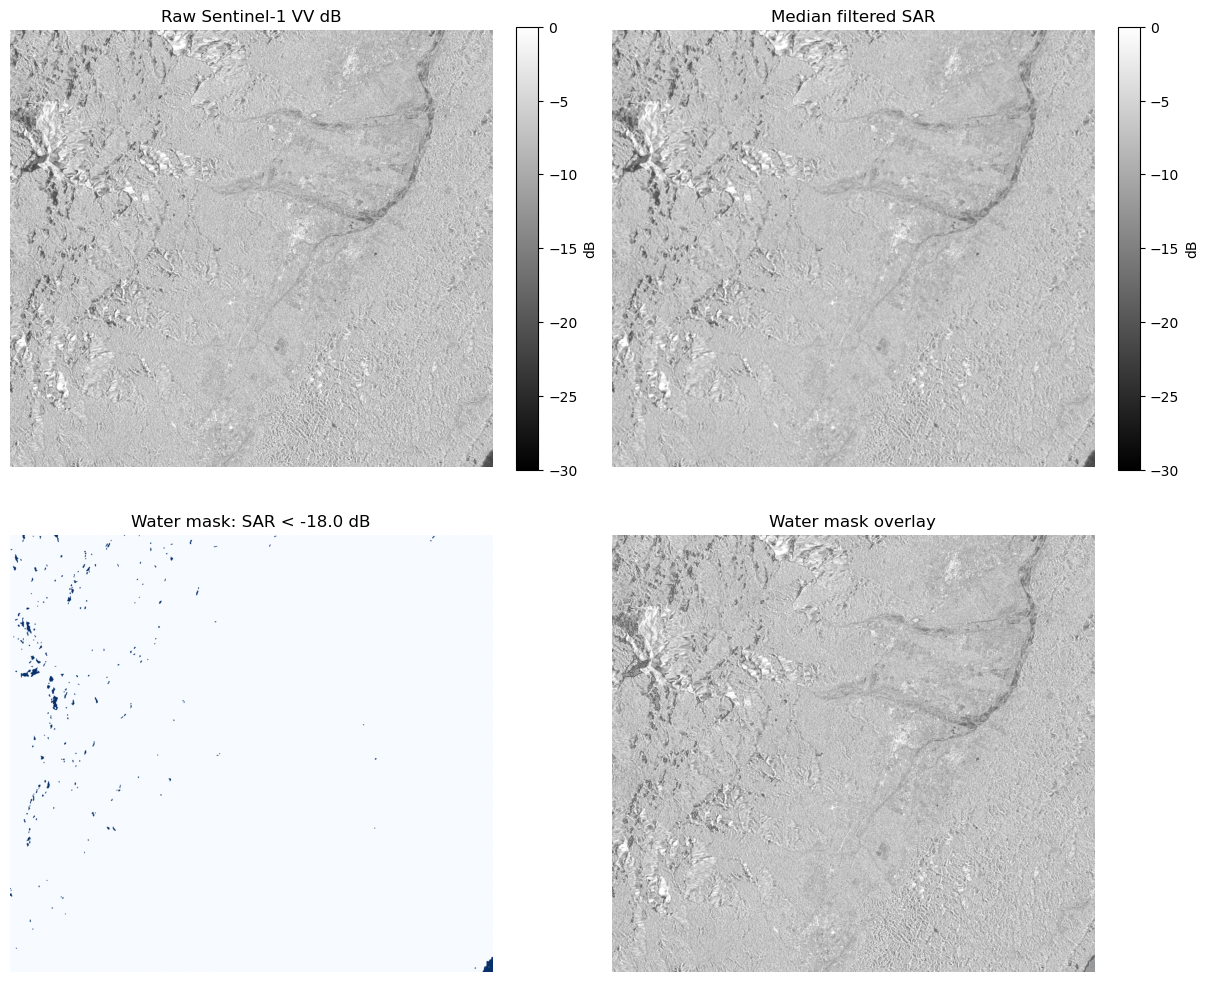

SAR detected 2.400 km² of possible flooding/water under cloudy conditions.


In [5]:
vmin, vmax = -30, 0

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
    constrained_layout=True
)

im0 = axes[0, 0].imshow(
    sar_db,
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)
axes[0, 0].set_title('Raw Sentinel-1 VV dB')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, label='dB')

im1 = axes[0, 1].imshow(
    sar_filtered,
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)
axes[0, 1].set_title('Median filtered SAR')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, label='dB')

axes[1, 0].imshow(
    water_clean,
    cmap='Blues'
)
axes[1, 0].set_title(f'Water mask: SAR < {SAR_THRESHOLD} dB')

axes[1, 1].imshow(
    sar_db,
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)
axes[1, 1].imshow(
    np.ma.masked_where(~water_clean, water_clean),
    alpha=0.45,
    cmap='Blues'
)
axes[1, 1].set_title('Water mask overlay')

for ax in axes.ravel():
    ax.set_axis_off()

plt.show()

print(f'SAR detected {flood_area_km2:.3f} km² of possible flooding/water under cloudy conditions.')